In [1]:
"""
PandaMap Analysis - Protein-Ligand Interaction Detection
Analyzes docked poses from AutoDock Vina, DiffDock, and EquiBind variants.
Supports TWO input modes:
  Mode A: PoseBusters CSV  → only poses that PASSED all quality tests
  Mode B: docking_directories dict → scan directories for all SDF poses (no filter)
"""

'\nPandaMap Analysis - Protein-Ligand Interaction Detection\nAnalyzes docked poses from AutoDock Vina, DiffDock, and EquiBind variants.\nSupports TWO input modes:\n  Mode A: PoseBusters CSV  → only poses that PASSED all quality tests\n  Mode B: docking_directories dict → scan directories for all SDF poses (no filter)\n'

# Imports

In [2]:
import os
import re
import subprocess
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')


# Config

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================
wd = "/home/manndo/master_dev"

# Protein files directory
proteins_dir = wd + "/Orai"

# Output directory for PandaMap results
output_dir = Path(wd + "/pandamap_results/")
output_dir.mkdir(exist_ok=True)

# ============================================================================
# INPUT MODE — choose exactly ONE
# ============================================================================
# Set USE_POSEBUSTERS_CSV = True  to load from the PoseBusters results CSV
# Set USE_POSEBUSTERS_CSV = False to scan docking_directories directly
USE_POSEBUSTERS_CSV = True

# --- Mode A: PoseBusters CSV path ---
pb_results_path = Path(wd) / "posebusters_results" / "posebusters_filtered_results.csv"

# The *real* PoseBusters quality-test columns (exclude metadata / count cols)
POSEBUSTERS_TEST_COLS = [
    'mol_pred_loaded', 'sanitization', 'inchi_convertible', 'all_atoms_connected',
    'no_radicals', 'bond_lengths', 'bond_angles', 'internal_steric_clash',
    'aromatic_ring_flatness', 'non-aromatic_ring_non-flatness', 'double_bond_flatness',
    'internal_energy', 'protein-ligand_maximum_distance', 'minimum_distance_to_protein',
    'volume_overlap_with_protein',
]

# --- Mode B: directory dict  {method_label: path_to_pose_directory} ---
autodock_poses_dir   = wd + "/docking_ready_mgltools/docking"
diffdock_poses_dir   = wd + "/diffdock_results"
equibind_guided_poses_dir    = wd + "/equibind_pocket_guided"
equibind_exclusion_poses_dir = wd + "/equibind_spatial_exclusion_poses"

docking_directories = {
    "autodock":            autodock_poses_dir,
    "diffdock":            diffdock_poses_dir,
    "equibind_guided":     equibind_guided_poses_dir,
    "equibind_exclusion":  equibind_exclusion_poses_dir,
}

In [4]:
# ============================================================================
# LOAD / FILTER POSES
# ============================================================================
all_poses: list[dict] = []

if USE_POSEBUSTERS_CSV:
    # ── Mode A: load CSV, keep only rows that pass every quality test ──
    print(f"Mode A: Loading PoseBusters results from\n  {pb_results_path}")
    df_pb = pd.read_csv(pb_results_path)
    print(f"  Total rows in CSV: {len(df_pb)}")

    available_tests = [c for c in POSEBUSTERS_TEST_COLS if c in df_pb.columns]
    for tc in available_tests:
        if df_pb[tc].dtype == object:
            df_pb[tc] = df_pb[tc].map({'True': True, 'true': True,
                                        'False': False, 'false': False})
        df_pb[tc] = df_pb[tc].astype(bool)

    df_pb["all_passed"] = df_pb[available_tests].all(axis=1)
    df_passed = df_pb[df_pb["all_passed"]].copy()
    print(f"  Poses passing all {len(available_tests)} tests: {len(df_passed)}")

    # Build pose list directly from the CSV rows
    for _, row in df_passed.iterrows():
        pose_file = str(row["pose_file"])
        method    = str(row["docking_method"])
        protein   = str(row["protein"])
        ligand    = str(row["ligand"])
        pose_name = str(row.get("pose_name", Path(pose_file).stem))

        rank_match = re.search(r'(?:model|pose|rank)(\d+)', pose_name)
        rank = int(rank_match.group(1)) if rank_match else 0

        all_poses.append({
            "method":    method,
            "protein":   protein,
            "ligand":    ligand,
            "pose_file": pose_file,
            "pose_name": pose_name,
            "pose_rank": rank,
            "protein_file": str(row["protein_file_used"]) if "protein_file_used" in row.index else None,
        })

else:
    # ── Mode B: scan docking_directories for SDF files ──
    print("Mode B: Scanning docking_directories for SDF poses (no PoseBusters filter)")
    for method_label, dir_path in docking_directories.items():
        d = Path(dir_path)
        if not d.exists():
            print(f"  WARNING: {method_label} → {d} does not exist, skipping")
            continue

        sdf_files = sorted(d.rglob("*.sdf"))
        n_found = 0
        for sdf_file in sdf_files:
            # Try to extract protein & ligand from path
            # Patterns: LIGAND__PROTEIN  or  PROTEIN__LIGAND
            rel = sdf_file.relative_to(d)
            parts_candidates = [rel.parts[0]] if rel.parts else [sdf_file.stem]
            folder_or_stem = parts_candidates[0]
            pair_parts = folder_or_stem.split("__")

            if len(pair_parts) == 2:
                a, b = pair_parts
                # Heuristic: Orai in name → protein
                if "Orai" in b or "Fr" in b:
                    ligand, protein = a, b
                elif "Orai" in a or "Fr" in a:
                    protein, ligand = a, b
                else:
                    ligand, protein = a, b  # default
            else:
                protein = folder_or_stem
                ligand = sdf_file.stem

            # Clean trailing tags like _spatial_sites, _cleaned
            protein = re.sub(r'_spatial_sites$', '', protein)

            rank_match = re.search(r'(?:model|pose|rank)(\d+)', sdf_file.stem)
            rank = int(rank_match.group(1)) if rank_match else 0

            n_found += 1
            all_poses.append({
                "method":    method_label,
                "protein":   protein,
                "ligand":    ligand,
                "pose_file": str(sdf_file),
                "pose_name": f"{ligand}__{protein}/{sdf_file.name}",
                "pose_rank": rank,
                "protein_file": None,
            })

        print(f"  {method_label:20s}: {n_found} SDF files in {d}")

# ============================================================================
# SUMMARY
# ============================================================================
methods_found = sorted(set(p["method"] for p in all_poses))

print(f"\n{'='*60}")
print(f"PandaMap Analysis — collected {len(all_poses)} poses")
print(f"  Methods: {methods_found}")
for m in methods_found:
    count = sum(1 for p in all_poses if p["method"] == m)
    print(f"    {m:20s}: {count}")
print(f"  Output directory: {output_dir}")
print(f"{'='*60}")

Mode A: Loading PoseBusters results from
  /home/manndo/master_dev/posebusters_results/posebusters_filtered_results.csv
  Total rows in CSV: 4789
  Poses passing all 15 tests: 457

PandaMap Analysis — collected 457 poses
  Methods: ['autodock', 'diffdock', 'equibind_guided', 'euqibind_exclusion']
    autodock            : 360
    diffdock            : 89
    equibind_guided     : 2
    euqibind_exclusion  : 6
  Output directory: /home/manndo/master_dev/pandamap_results


In [5]:
"""
Helper functions to prepare complex structures for PandaMap.
PandaMap needs a combined protein-ligand file to detect interactions.
"""
from rdkit import Chem
from rdkit.Chem import AllChem

def combine_protein_ligand_to_pdb(protein_pdb: str, ligand_file: str, output_pdb: str, ligand_resname: str = "LIG") -> bool:
    """
    Combine protein PDB and ligand (SDF/PDB) into a single PDB file for PandaMap.
    
    Args:
        protein_pdb: Path to protein PDB file
        ligand_file: Path to ligand file (SDF or PDB)
        output_pdb: Path for combined output PDB
        ligand_resname: Residue name for ligand (default: LIG)
    
    Returns:
        True if successful, False otherwise
    """
    try:
        # Read protein PDB content (exclude END line)
        with open(protein_pdb, 'r') as f:
            protein_lines = [line for line in f if not line.startswith('END')]
        
        # Read ligand and convert to PDB format
        ligand_ext = Path(ligand_file).suffix.lower()
        
        if ligand_ext == '.sdf':
            mol = Chem.MolFromMolFile(ligand_file, removeHs=False)
        elif ligand_ext == '.pdb':
            mol = Chem.MolFromPDBFile(ligand_file, removeHs=False)
        elif ligand_ext == '.pdbqt':
            # For PDBQT, read as PDB (ignoring charges)
            mol = Chem.MolFromPDBFile(ligand_file, removeHs=False, sanitize=False)
        else:
            print(f"  Unsupported ligand format: {ligand_ext}")
            return False
        
        if mol is None:
            print(f"  Failed to read ligand: {ligand_file}")
            return False
        
        # Convert ligand to PDB block
        ligand_pdb = Chem.MolToPDBBlock(mol)
        
        # Modify ligand PDB to use custom residue name and chain X
        modified_ligand_lines = []
        for line in ligand_pdb.split('\n'):
            if line.startswith(('HETATM', 'ATOM')):
                # Replace residue name (columns 18-20) and chain (column 22)
                new_line = line[:17] + f"{ligand_resname:>3}" + 'X' + line[21:]
                modified_ligand_lines.append(new_line)
            elif line.startswith('CONECT'):
                modified_ligand_lines.append(line)
        
        # Write combined file
        with open(output_pdb, 'w') as f:
            f.writelines(protein_lines)
            f.write('\n')
            for line in modified_ligand_lines:
                f.write(line + '\n')
            f.write('END\n')
        
        return True
        
    except Exception as e:
        print(f"  Error combining files: {e}")
        return False


def find_protein_for_pose(pose_info: dict, proteins_dir: str) -> str:
    """Find the corresponding protein PDB file for a docked pose."""
    protein_name = pose_info.get("protein", "")
    
    # Clean up protein name (remove prefixes like mgl_, mko_)
    clean_name = protein_name
    for prefix in ['mgl_', 'mko_']:
        if clean_name.startswith(prefix):
            clean_name = clean_name[len(prefix):]
    
    # Remove suffixes like _pymol_fixed, _pm_saved, etc.
    for suffix in ['_pymol_fixed', '_pymol_export', '_pm_saved', '_amber_clean', '_amber', '_retry1']:
        clean_name = clean_name.replace(suffix, '')
    
    # Search for protein file
    proteins_path = Path(proteins_dir)
    
    patterns = [
        f"{clean_name}.pdb",
        f"{clean_name}_protein.pdb",
        f"*{clean_name}*.pdb",
    ]
    
    for pattern in patterns:
        matches = list(proteins_path.glob(pattern))
        if matches:
            return str(matches[0])
    
    # Also search in subdirectories
    for pattern in patterns:
        matches = list(proteins_path.glob(f"**/{pattern}"))
        if matches:
            return str(matches[0])
    
    return None

print("Helper functions loaded successfully!")

Helper functions loaded successfully!


In [6]:
"""
Validate collected poses — check that every pose file exists on disk
"""
from pathlib import Path

n_missing = 0
for pose in all_poses:
    if not Path(pose["pose_file"]).exists():
        n_missing += 1
        if n_missing <= 5:
            print(f"  MISSING: {pose['pose_file']}")

if n_missing:
    print(f"\nWARNING: {n_missing}/{len(all_poses)} pose files not found on disk!")
    # Optionally drop them
    all_poses = [p for p in all_poses if Path(p["pose_file"]).exists()]
    print(f"  Kept {len(all_poses)} valid poses")
else:
    print(f"All {len(all_poses)} pose files verified on disk ✓")

# Quick breakdown by method × protein × ligand
combos = defaultdict(int)
for p in all_poses:
    combos[(p["method"], p["protein"], p["ligand"])] += 1

print(f"\nUnique (method, protein, ligand) combos: {len(combos)}")
for (m, prot, lig), cnt in sorted(combos.items()):
    print(f"  {m:20s} | {prot:40s} | {lig:25s} → {cnt} poses")

All 457 pose files verified on disk ✓

Unique (method, protein, ligand) combos: 28
  autodock             | Orai1WT-MDSnap-Fr300_cleaned             | 2abp-nh2-OPT              → 30 poses
  autodock             | Orai1WT-MDSnap-Fr300_cleaned             | Synta-66-OPT-Singlet      → 30 poses
  autodock             | Orai1WT-MDSnap-Fr300_cleaned             | gsk7975a-prot-OPT         → 30 poses
  autodock             | Orai1WT-MDSnap-Fr400_cleaned             | 2abp-nh2-OPT              → 30 poses
  autodock             | Orai1WT-MDSnap-Fr400_cleaned             | Synta-66-OPT-Singlet      → 30 poses
  autodock             | Orai1WT-MDSnap-Fr400_cleaned             | gsk7975a-prot-OPT         → 30 poses
  autodock             | Orai1WT-MDSnap-Fr499_cleaned             | 2abp-nh2-OPT              → 30 poses
  autodock             | Orai1WT-MDSnap-Fr499_cleaned             | Synta-66-OPT-Singlet      → 30 poses
  autodock             | Orai1WT-MDSnap-Fr499_cleaned             | gsk7975a-

# Build Protein Lookup Table

In [7]:
"""
Build protein PDB lookup table.
If Mode A was used, poses already carry a protein_file path from the CSV.
This cell builds a fallback lookup from the Orai/ directory.
"""
# Map protein names to their PDB files
protein_pdb_files = {}

# Search for protein files in Orai directory
orai_dir = Path(proteins_dir)
if orai_dir.exists():
    for pdb_file in orai_dir.glob("*.pdb"):
        protein_pdb_files[pdb_file.stem] = str(pdb_file)

# Also check docking_ready_mgltools
docking_ready = Path(wd) / "docking_ready_mgltools"
if docking_ready.exists():
    for pdb_file in docking_ready.rglob("*.pdb"):
        if "ligand" not in pdb_file.name.lower():
            name = pdb_file.stem
            if name not in protein_pdb_files:
                protein_pdb_files[name] = str(pdb_file)

print(f"Found {len(protein_pdb_files)} protein PDB files in lookup table")
for name in sorted(protein_pdb_files)[:6]:
    print(f"  {name}: {protein_pdb_files[name]}")

# Pre-populate pose entries that already have a protein_file from the CSV
n_from_csv = sum(1 for p in all_poses if p.get("protein_file") and Path(p["protein_file"]).exists())
print(f"\nPoses with protein_file already set (from CSV): {n_from_csv}/{len(all_poses)}")

Found 9 protein PDB files in lookup table
  2abp-nh2-OPT: /home/manndo/master_dev/docking_ready_mgltools/2abp-nh2-OPT.pdb
  2abp-nh3p-OPT: /home/manndo/master_dev/docking_ready_mgltools/2abp-nh3p-OPT.pdb
  Orai1WT-MDSnap-Fr300_cleaned: /home/manndo/master_dev/Orai/Orai1WT-MDSnap-Fr300_cleaned.pdb
  Orai1WT-MDSnap-Fr400_cleaned: /home/manndo/master_dev/Orai/Orai1WT-MDSnap-Fr400_cleaned.pdb
  Orai1WT-MDSnap-Fr499_cleaned: /home/manndo/master_dev/Orai/Orai1WT-MDSnap-Fr499_cleaned.pdb
  Orai1WT-START-Fr0_cleaned: /home/manndo/master_dev/Orai/Orai1WT-START-Fr0_cleaned.pdb

Poses with protein_file already set (from CSV): 457/457


#  Pandamaps Execution

In [8]:
"""
Run PandaMap analysis on docked poses
"""
from pandamap import HybridProtLigMapper
import traceback

def get_protein_file(pose_info: dict) -> str:
    """
    Get the protein PDB file for a pose.
    Priority: pose-level protein_file (from CSV)  →  lookup table  →  partial match.
    """
    # 1. Pose already has a protein_file (Mode A / CSV)
    pf = pose_info.get("protein_file")
    if pf and Path(pf).exists():
        return pf

    protein_name = pose_info.get("protein", "")

    # 2. Direct match in lookup table
    if protein_name in protein_pdb_files:
        return protein_pdb_files[protein_name]

    # 3. Clean up protein name and retry
    clean_name = protein_name
    for prefix in ['mgl_', 'mko_']:
        if clean_name.startswith(prefix):
            clean_name = clean_name[len(prefix):]
    for suffix in ['_pymol_fixed', '_pymol_export', '_pm_saved',
                    '_amber_clean', '_amber', '_retry1',
                    '_spatial_sites']:
        clean_name = clean_name.replace(suffix, '')

    if clean_name in protein_pdb_files:
        return protein_pdb_files[clean_name]

    # 4. Partial / substring match
    for name, path in protein_pdb_files.items():
        if clean_name in name or name in clean_name:
            return path

    return None


def run_pandamap_analysis(pose_info: dict, output_dir: Path, use_dssp: bool = False) -> dict:
    """
    Run PandaMap analysis on a single docked pose.
    Returns dict with interaction summary or error info.
    """
    pose_file   = pose_info["pose_file"]
    protein_name = pose_info["protein"]
    ligand_name  = pose_info["ligand"]
    method       = pose_info["method"]
    pose_name    = pose_info["pose_name"]

    # Find protein file
    protein_file = get_protein_file(pose_info)
    if not protein_file:
        return {"error": f"Protein file not found for {protein_name}"}

    # Create output subdirectory
    safe_name = pose_name.replace("/", "_").replace("\\", "_")
    analysis_dir = output_dir / method / f"{protein_name}__{ligand_name}"
    analysis_dir.mkdir(parents=True, exist_ok=True)

    # Combine protein and ligand into single PDB
    combined_pdb = analysis_dir / f"{safe_name}_complex.pdb"

    if not combine_protein_ligand_to_pdb(protein_file, pose_file, str(combined_pdb), "LIG"):
        return {"error": "Failed to create combined PDB"}

    try:
        mapper = HybridProtLigMapper(str(combined_pdb), ligand_resname="LIG")

        # Generate 2D visualization path BEFORE run_analysis
        images_dir = analysis_dir / "images"
        images_dir.mkdir(parents=True, exist_ok=True)
        output_image = images_dir / f"{safe_name}_interactions.png"

        # Pass output_file to run_analysis so PandaMap saves directly
        # to the correct location (otherwise it defaults to cwd)
        mapper.run_analysis(output_file=str(output_image), use_dssp=use_dssp)

        # Extract interaction summary
        interactions = mapper.interactions if hasattr(mapper, 'interactions') else {}
        interaction_counts = {}
        for int_type, int_list in interactions.items():
            if isinstance(int_list, list):
                interaction_counts[int_type] = len(int_list)

        return {
            "method": method,
            "protein": protein_name,
            "ligand": ligand_name,
            "pose_name": pose_name,
            "pose_file": pose_file,
            "output_image": str(output_image),
            "interactions": interaction_counts,
            "total_interactions": sum(interaction_counts.values()),
            "error": None,
        }

    except Exception as e:
        return {
            "method": method,
            "protein": protein_name,
            "ligand": ligand_name,
            "pose_name": pose_name,
            "error": str(e),
        }

print("PandaMap analysis function ready!")

PandaMap analysis function ready!


In [9]:
"""
Select representative poses (first / best-ranked pose per protein-ligand-method combo)
"""
# Sort by rank so the first seen is the top-ranked pose
sorted_poses = sorted(all_poses, key=lambda p: p["pose_rank"])

selected_poses = []
seen = set()

for pose in sorted_poses:
    key = (pose["method"], pose["protein"], pose["ligand"])
    if key not in seen:
        seen.add(key)
        selected_poses.append(pose)

print(f"Selected {len(selected_poses)} representative poses for analysis")
for m in methods_found:
    cnt = sum(1 for p in selected_poses if p["method"] == m)
    print(f"  {m:20s}: {cnt}")

Selected 28 representative poses for analysis
  autodock            : 12
  diffdock            : 12
  equibind_guided     : 2
  euqibind_exclusion  : 2


In [10]:
from tqdm import tqdm

"""
Run FULL PandaMap analysis on ALL selected poses
This will analyze all PoseBusters-proved representative poses and save results
"""

# Create separate output directory for full analysis
full_analysis_dir = output_dir / "full_analysis"
full_analysis_dir.mkdir(exist_ok=True)

print(f"Running FULL PandaMap analysis on ALL {len(selected_poses)} selected poses")
print(f"Output directory: {full_analysis_dir}")
print("=" * 60)

all_results = []
all_errors = []

# Analyze all selected poses
for pose in tqdm(selected_poses, desc="Full Analysis"):
    result = run_pandamap_analysis(pose, full_analysis_dir, use_dssp=False)
    
    if result.get("error"):
        all_errors.append(result)
    else:
        all_results.append(result)

print(f"\nFull analysis completed!")
print(f"  Successful: {len(all_results)} poses")
print(f"  Failed: {len(all_errors)} poses")

# Save full results
if all_results:
    full_results_df = pd.DataFrame(all_results)
    
    # Expand interactions dict into columns
    interaction_types = set()
    for r in all_results:
        if isinstance(r.get("interactions"), dict):
            interaction_types.update(r["interactions"].keys())
    
    for int_type in interaction_types:
        full_results_df[int_type] = full_results_df["interactions"].apply(
            lambda x: x.get(int_type, 0) if isinstance(x, dict) else 0
        )
    
    # Save to CSV
    full_results_file = full_analysis_dir / "pandamap_full_results.csv"
    full_results_df.to_csv(full_results_file, index=False)
    print(f"\nFull results saved to: {full_results_file}")
    
    # Print summary statistics
    print("\n" + "=" * 60)
    print("FULL ANALYSIS SUMMARY BY DOCKING METHOD")
    print("=" * 60)
    
    int_cols = [c for c in full_results_df.columns if c in interaction_types]
    if int_cols:
        summary_full = full_results_df.groupby("method")[int_cols + ["total_interactions"]].mean()
        print("\nAverage interactions per pose:")
        print(summary_full.round(2).to_string())
    
    print("\n" + "-" * 60)
    print("Total interactions distribution:")
    print(full_results_df.groupby("method")["total_interactions"].describe().round(2))
    
    # Count by method
    print("\n" + "-" * 60)
    print("Poses analyzed per method:")
    print(full_results_df["method"].value_counts())
else:
    print("\nNo successful results to save.")

# Save error log if any
if all_errors:
    errors_df = pd.DataFrame(all_errors)
    errors_file = full_analysis_dir / "pandamap_errors.csv"
    errors_df.to_csv(errors_file, index=False)
    print(f"\nError log saved to: {errors_file}")
    print("\nSample errors:")
    for err in all_errors[:5]:
        print(f"  {err.get('pose_name', 'unknown')}: {err.get('error', 'unknown error')}")

Running FULL PandaMap analysis on ALL 28 selected poses
Output directory: /home/manndo/master_dev/pandamap_results/full_analysis


Full Analysis:   0%|          | 0/28 [00:00<?, ?it/s]

Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 3 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 4
Marking ('ALA', 94) as solvent accessible (score: 0.81)
Marking ('LEU', 95) as solvent accessible (score: 0.83)
Marking ('ARG', 91) as solvent accessible (score: 1.08)
Marking ('LYS', 87) as solvent accessible (score: 1.12)
Constraints: min=1, max=2 solvent accessible residues
Too many solvent-accessible residues detected (4), removing lowest scoring ones...
Removing ('ALA', 94) from solvent accessible (score: 0.81)
Removing ('LEU', 95) from solvent accessible (score: 0.83)
Final result: 2 solvent-accessible residues out of 4 interacting residues
Solvent accessible residues: [('ARG', 91), ('LYS', 87)]
Generating visualization...

=== VISUALIZATION DEBUG ===
Total interacting residues: 4
Solvent accessible residues: 2
So

Full Analysis:   4%|▎         | 1/28 [00:01<00:27,  1.02s/it]

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/full_analysis/equibind_guided/Orai1WT-START-Fr0_cleaned__2abp-nh2-OPT/images/2abp-nh2-OPT__Orai1WT-START-Fr0_cleaned_prep_conformers_seed8675_c1.sdf_interactions.png
Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 19 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 17
Marking ('PHE', 253) as solvent accessible (score: 0.79)
Marking ('VAL', 133) as solvent accessible (score: 0.72)
Marking ('THR', 180) as solvent accessible (score: 0.98)
Marking ('VAL', 181) as solvent accessible (score: 0.77)
Marking ('PHE', 178) as solvent accessible (score: 0.72)
Marking ('ILE', 182) as solvent accessible (score: 0.68)
Marking ('ALA', 254) as solvent accessible (score: 0.81)
Marking ('PHE', 136) as solvent accessible (score: 0.75)
Marking ('VAL', 129) as solvent acc

...

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/full_analysis/diffdock/Orai1WT-MDSnap-Fr499_cleaned__Synta-66-OPT-Singlet/images/Synta-66-OPT-Singlet__Orai1WT-MDSnap-Fr499_cleaned_complex_0_rank12_confidence-2.70.sdf_interactions.png
Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 0 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible residues
Too few solvent-accessible residues detected (0), adding more based on scores...
Too many solvent-accessible residues detected (0), removing lowest scoring ones...
Final result: 0 solvent-accessible residues out of 0 interacting residues
Applying stricter filtering
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent acces

Full Analysis:  96%|█████████▋| 27/28 [00:26<00:00,  1.33it/s]

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/full_analysis/diffdock/Orai1WT-MDSnap-Fr400_cleaned__gsk7975a-prot-OPT/images/gsk7975a-prot-OPT__Orai1WT-MDSnap-Fr400_cleaned_complex_0_rank18_confidence-3.69.sdf_interactions.png
Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 0 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible residues
Too few solvent-accessible residues detected (0), adding more based on scores...
Too many solvent-accessible residues detected (0), removing lowest scoring ones...
Final result: 0 solvent-accessible residues out of 0 interacting residues
Applying stricter filtering
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible 

Full Analysis: 100%|██████████| 28/28 [00:26<00:00,  1.05it/s]

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/full_analysis/diffdock/Orai1WT-START-Fr0_cleaned__Synta-66-OPT-Singlet/images/Synta-66-OPT-Singlet__Orai1WT-START-Fr0_cleaned_complex_0_rank18_confidence-2.88.sdf_interactions.png

Full analysis completed!
  Successful: 28 poses
  Failed: 0 poses

Full results saved to: /home/manndo/master_dev/pandamap_results/full_analysis/pandamap_full_results.csv

FULL ANALYSIS SUMMARY BY DOCKING METHOD

Average interactions per pose:
                    alkyl_pi  amide_pi  salt_bridge  donor_pi  ionic  metal_coordination  halogen_bonds  covalent  pi_pi_stacking  hydrophobic  cation_pi  attractive_charge  repulsion  hydrogen_bonds  carbon_pi  pi_cation  total_interactions
method                                                                                                                                                                                                                                           
autodock             

In [11]:
"""
Run PandaMap analysis on selected poses
This may take a while depending on the number of poses
"""
from tqdm import tqdm

results = []
errors = []

# Limit to first few for testing (remove slice for full analysis)
poses_to_analyze = selected_poses[:]  # Analyze first 20 for testing

print(f"Analyzing {len(poses_to_analyze)} poses with PandaMap...")
print("=" * 60)

for pose in tqdm(poses_to_analyze, desc="Analyzing poses"):
    result = run_pandamap_analysis(pose, output_dir, use_dssp=False)
    
    if result.get("error"):
        errors.append(result)
    else:
        results.append(result)

print(f"\nCompleted: {len(results)} successful, {len(errors)} failed")

# Show some errors if any
if errors[:3]:
    print("\nSample errors:")
    for err in errors[:3]:
        print(f"  {err.get('pose_name', 'unknown')}: {err.get('error', 'unknown error')}")

Analyzing 28 poses with PandaMap...


Analyzing poses:   0%|          | 0/28 [00:00<?, ?it/s]

Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 3 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 4
Marking ('ALA', 94) as solvent accessible (score: 0.81)
Marking ('LEU', 95) as solvent accessible (score: 0.83)
Marking ('ARG', 91) as solvent accessible (score: 1.08)
Marking ('LYS', 87) as solvent accessible (score: 1.12)
Constraints: min=1, max=2 solvent accessible residues
Too many solvent-accessible residues detected (4), removing lowest scoring ones...
Removing ('ALA', 94) from solvent accessible (score: 0.81)
Removing ('LEU', 95) from solvent accessible (score: 0.83)
Final result: 2 solvent-accessible residues out of 4 interacting residues
Solvent accessible residues: [('ARG', 91), ('LYS', 87)]
Generating visualization...

=== VISUALIZATION DEBUG ===
Total interacting residues: 4
Solvent accessible residues: 2
So

Analyzing poses:   4%|▎         | 1/28 [00:00<00:26,  1.02it/s]

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/equibind_guided/Orai1WT-START-Fr0_cleaned__2abp-nh2-OPT/images/2abp-nh2-OPT__Orai1WT-START-Fr0_cleaned_prep_conformers_seed8675_c1.sdf_interactions.png
Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 19 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 17
Marking ('PHE', 253) as solvent accessible (score: 0.79)
Marking ('VAL', 133) as solvent accessible (score: 0.72)
Marking ('THR', 180) as solvent accessible (score: 0.98)
Marking ('VAL', 181) as solvent accessible (score: 0.77)
Marking ('PHE', 178) as solvent accessible (score: 0.72)
Marking ('ILE', 182) as solvent accessible (score: 0.68)
Marking ('ALA', 254) as solvent accessible (score: 0.81)
Marking ('PHE', 136) as solvent accessible (score: 0.75)
Marking ('VAL', 129) as solvent accessible (score

...

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/diffdock/Orai1WT-MDSnap-Fr499_cleaned__Synta-66-OPT-Singlet/images/Synta-66-OPT-Singlet__Orai1WT-MDSnap-Fr499_cleaned_complex_0_rank12_confidence-2.70.sdf_interactions.png
Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 0 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible residues
Too few solvent-accessible residues detected (0), adding more based on scores...
Too many solvent-accessible residues detected (0), removing lowest scoring ones...
Final result: 0 solvent-accessible residues out of 0 interacting residues
Applying stricter filtering
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible residues

Analyzing poses:  96%|█████████▋| 27/28 [00:26<00:00,  1.33it/s]

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/diffdock/Orai1WT-MDSnap-Fr400_cleaned__gsk7975a-prot-OPT/images/gsk7975a-prot-OPT__Orai1WT-MDSnap-Fr400_cleaned_complex_0_rank18_confidence-3.69.sdf_interactions.png
Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 0 total interactions
Calculating solvent accessibility...
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible residues
Too few solvent-accessible residues detected (0), adding more based on scores...
Too many solvent-accessible residues detected (0), removing lowest scoring ones...
Final result: 0 solvent-accessible residues out of 0 interacting residues
Applying stricter filtering
Using realistic solvent accessibility calculation...
Total protein atoms: 3509
Interacting residues to check: 0
Constraints: min=1, max=-1 solvent accessible residues
Too f

Analyzing poses: 100%|██████████| 28/28 [00:26<00:00,  1.05it/s]

Interaction diagram saved to /home/manndo/master_dev/pandamap_results/diffdock/Orai1WT-START-Fr0_cleaned__Synta-66-OPT-Singlet/images/Synta-66-OPT-Singlet__Orai1WT-START-Fr0_cleaned_complex_0_rank18_confidence-2.88.sdf_interactions.png

Completed: 28 successful, 0 failed


In [12]:
"""
Summarize interaction results
"""
if results:
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Expand interactions dict into columns
    interaction_types = set()
    for r in results:
        if isinstance(r.get("interactions"), dict):
            interaction_types.update(r["interactions"].keys())
    
    for int_type in interaction_types:
        results_df[int_type] = results_df["interactions"].apply(
            lambda x: x.get(int_type, 0) if isinstance(x, dict) else 0
        )
    
    # Save results
    results_file = output_dir / "pandamap_results.csv"
    results_df.to_csv(results_file, index=False)
    print(f"Results saved to: {results_file}")
    
    # Summary by method
    print("\n" + "=" * 60)
    print("INTERACTION SUMMARY BY DOCKING METHOD")
    print("=" * 60)
    
    int_cols = [c for c in results_df.columns if c in interaction_types]
    if int_cols:
        summary = results_df.groupby("method")[int_cols + ["total_interactions"]].mean()
        print("\nAverage interactions per pose:")
        print(summary.round(2).to_string())
    
    # Total interactions distribution
    print("\n" + "-" * 60)
    print("Total interactions per pose:")
    print(results_df.groupby("method")["total_interactions"].describe().round(2))
    
else:
    print("No successful results to summarize.")

Results saved to: /home/manndo/master_dev/pandamap_results/pandamap_results.csv

INTERACTION SUMMARY BY DOCKING METHOD

Average interactions per pose:
                    alkyl_pi  amide_pi  salt_bridge  donor_pi  ionic  metal_coordination  halogen_bonds  covalent  pi_pi_stacking  hydrophobic  cation_pi  attractive_charge  repulsion  hydrogen_bonds  carbon_pi  pi_cation  total_interactions
method                                                                                                                                                                                                                                           
autodock                1.00      0.17          0.0      0.17    0.0                 0.0           0.17       0.0            0.58         0.83       0.42                0.0        0.0            0.50       0.58       0.42                4.83
diffdock                1.42      0.08          0.0      0.17    0.0                 0.0           0.17       0.0          

Figure saved to: /home/manndo/master_dev/pandamap_results/interaction_comparison.png


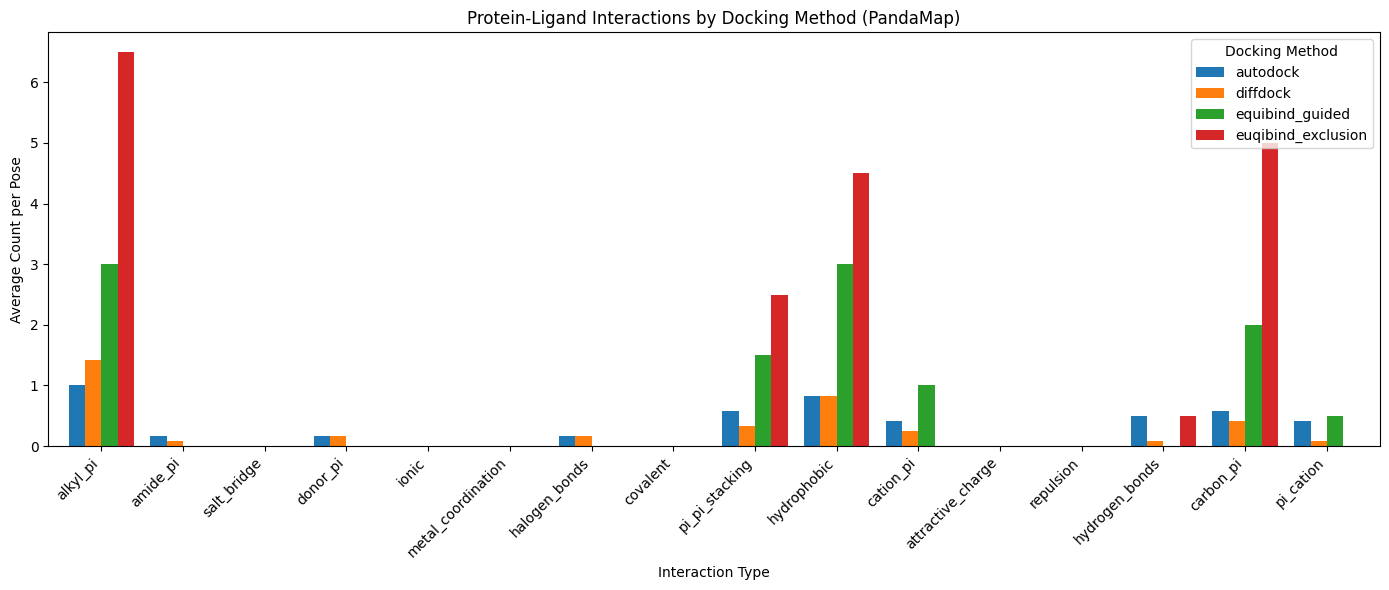

Figure saved to: /home/manndo/master_dev/pandamap_results/total_interactions_boxplot.png


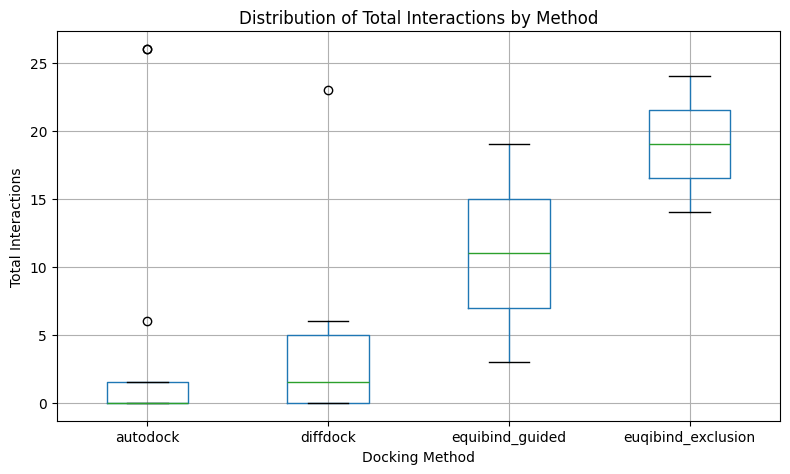

In [13]:
"""
Visualize interaction comparison across docking methods
"""
%matplotlib inline
import matplotlib.pyplot as plt

if results and 'results_df' in dir() and not results_df.empty:
    # Get interaction type columns
    int_cols = [c for c in results_df.columns if c in interaction_types]
    
    if int_cols:
        # Calculate mean interactions by method
        method_means = results_df.groupby("method")[int_cols].mean()
        
        # Create grouped bar chart
        fig, ax = plt.subplots(figsize=(14, 6))
        method_means.T.plot(kind='bar', ax=ax, width=0.8)
        
        ax.set_ylabel("Average Count per Pose")
        ax.set_xlabel("Interaction Type")
        ax.set_title("Protein-Ligand Interactions by Docking Method (PandaMap)")
        ax.legend(title="Docking Method", loc='upper right')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        # Save figure
        fig_file = output_dir / "interaction_comparison.png"
        plt.savefig(fig_file, dpi=150)
        print(f"Figure saved to: {fig_file}")
        plt.show()
    
    # Also show total interactions comparison
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    results_df.boxplot(column="total_interactions", by="method", ax=ax2)
    ax2.set_ylabel("Total Interactions")
    ax2.set_xlabel("Docking Method")
    ax2.set_title("Distribution of Total Interactions by Method")
    plt.suptitle("")  # Remove automatic title
    plt.tight_layout()
    
    fig2_file = output_dir / "total_interactions_boxplot.png"
    plt.savefig(fig2_file, dpi=150)
    print(f"Figure saved to: {fig2_file}")
    plt.show()
else:
    print("No results available for visualization.")

Sample Interaction Maps:

AUTODOCK: Synta-66-OPT-Singlet + Orai1WT-MDSnap-Fr499_cleaned
Total interactions: 0


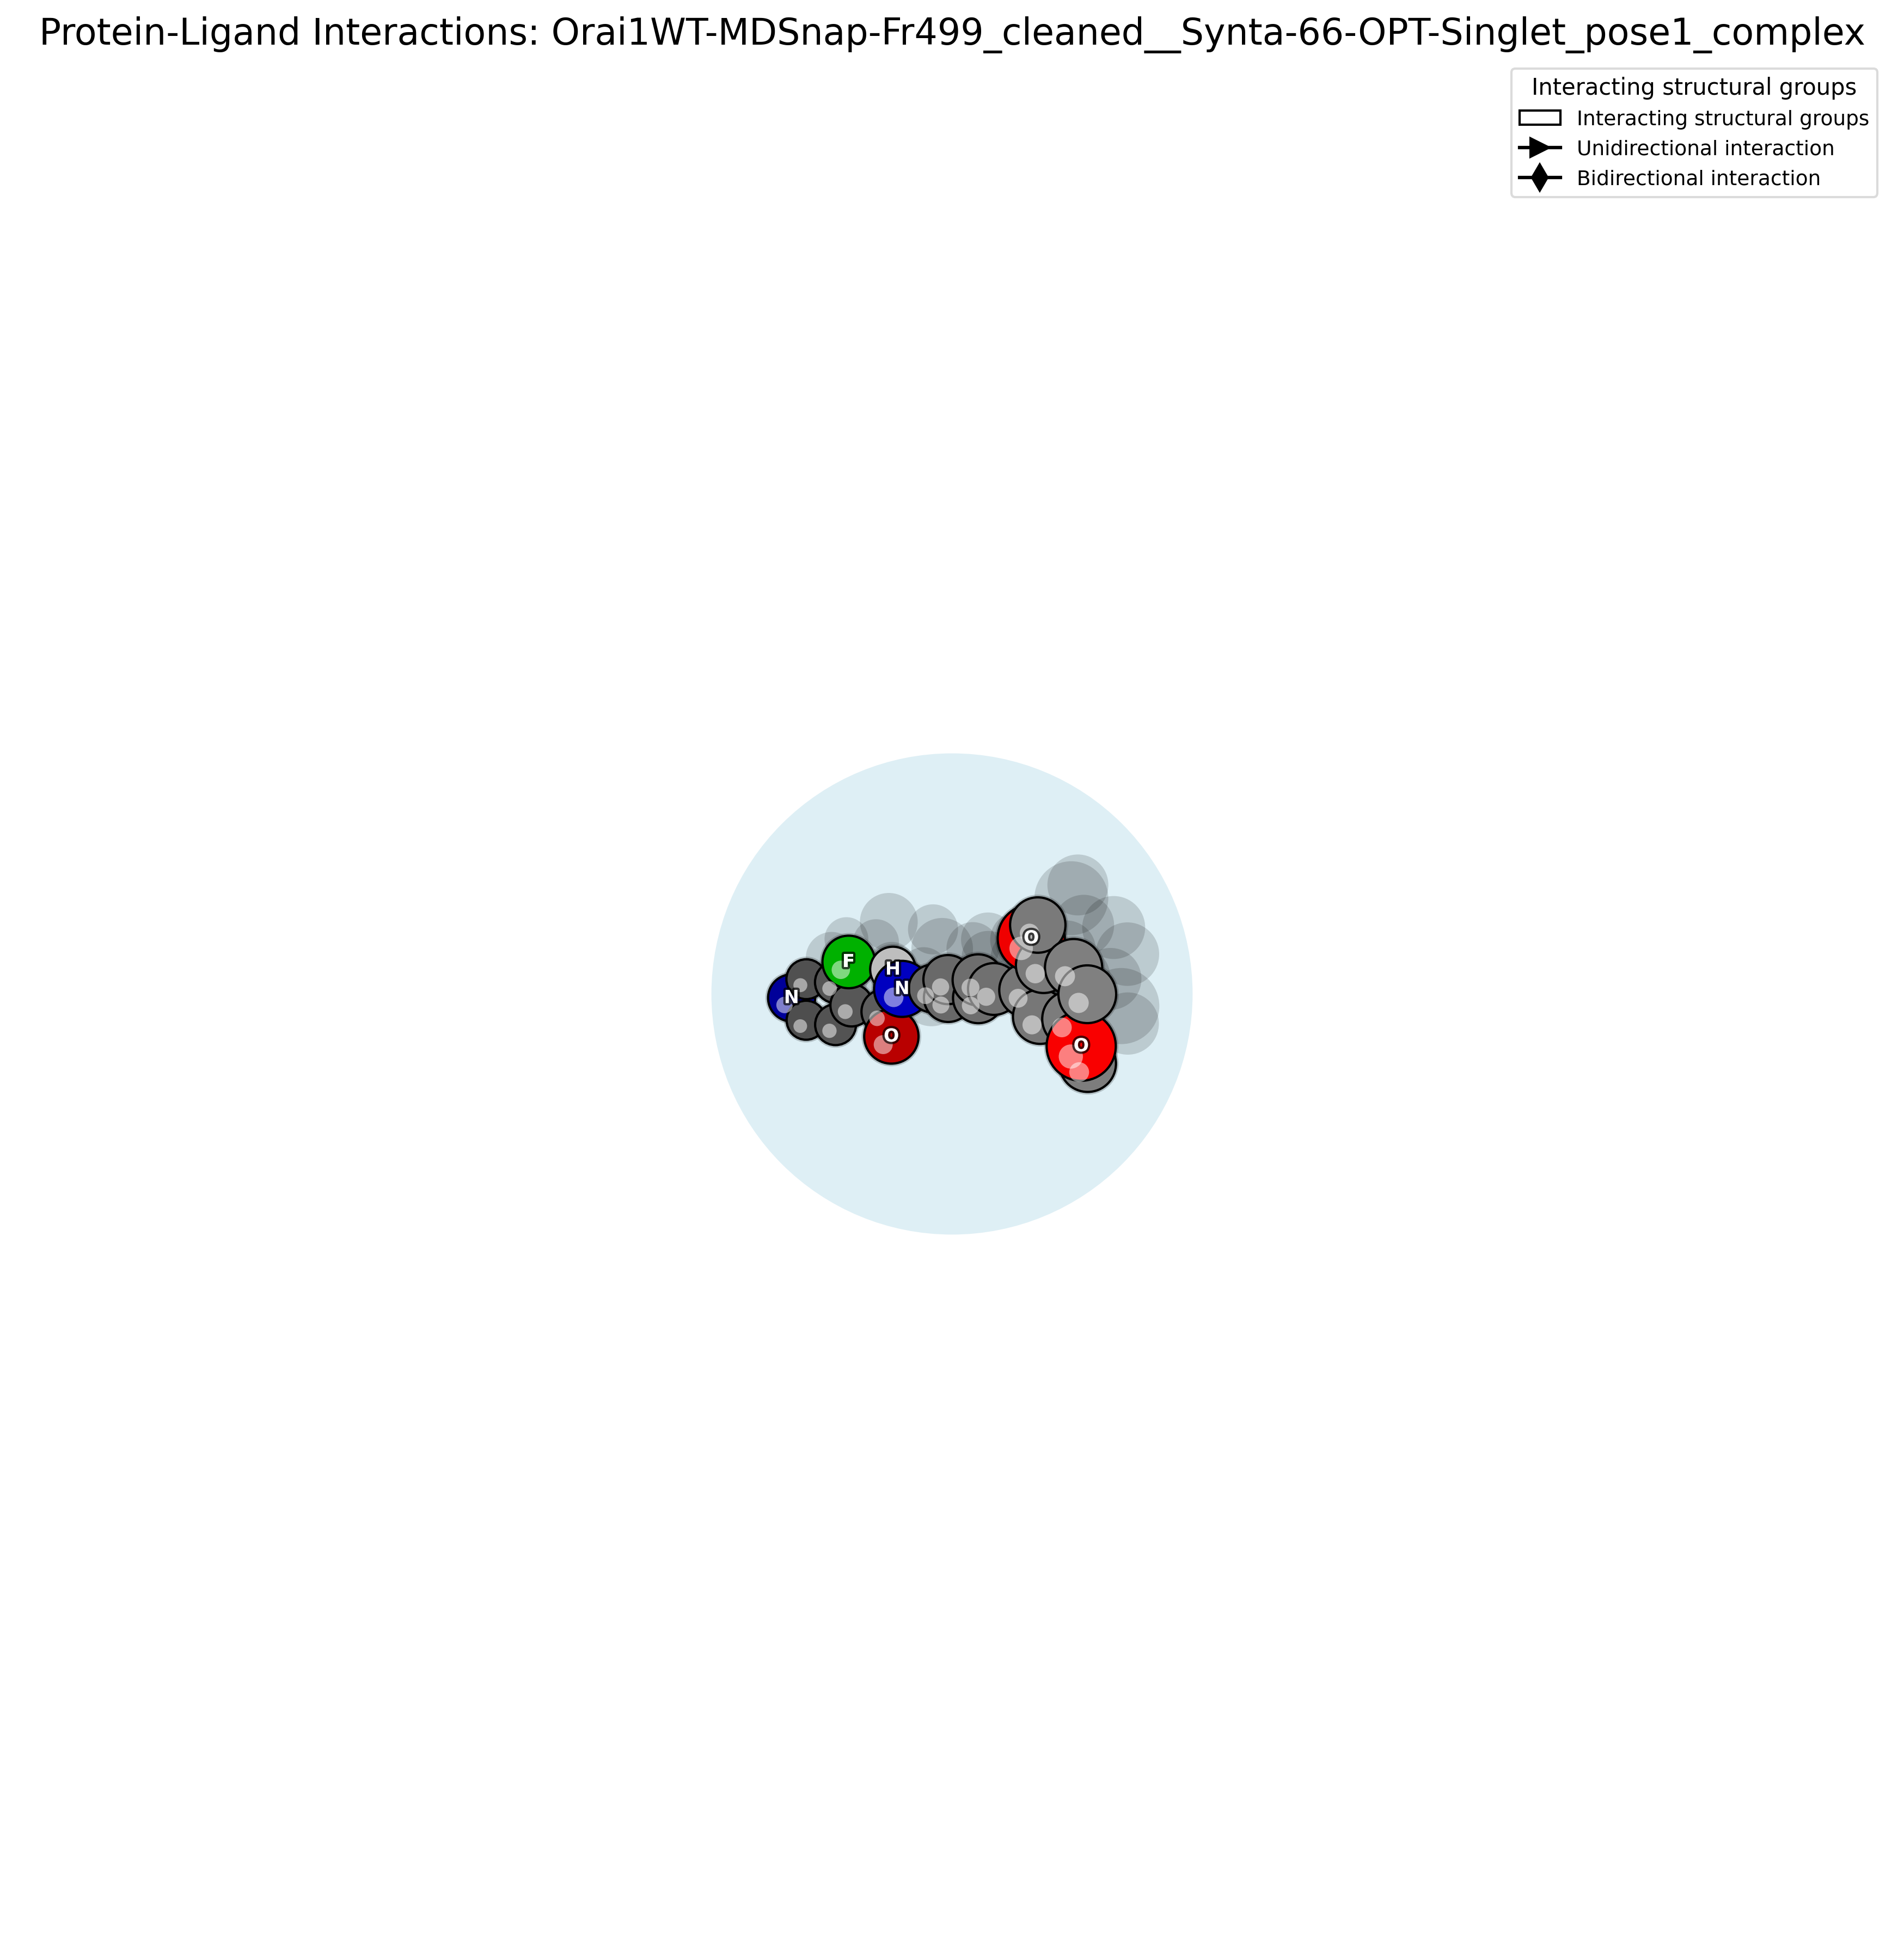


DIFFDOCK: 2abp-nh2-OPT + Orai1WT-START-Fr0_cleaned
Total interactions: 5


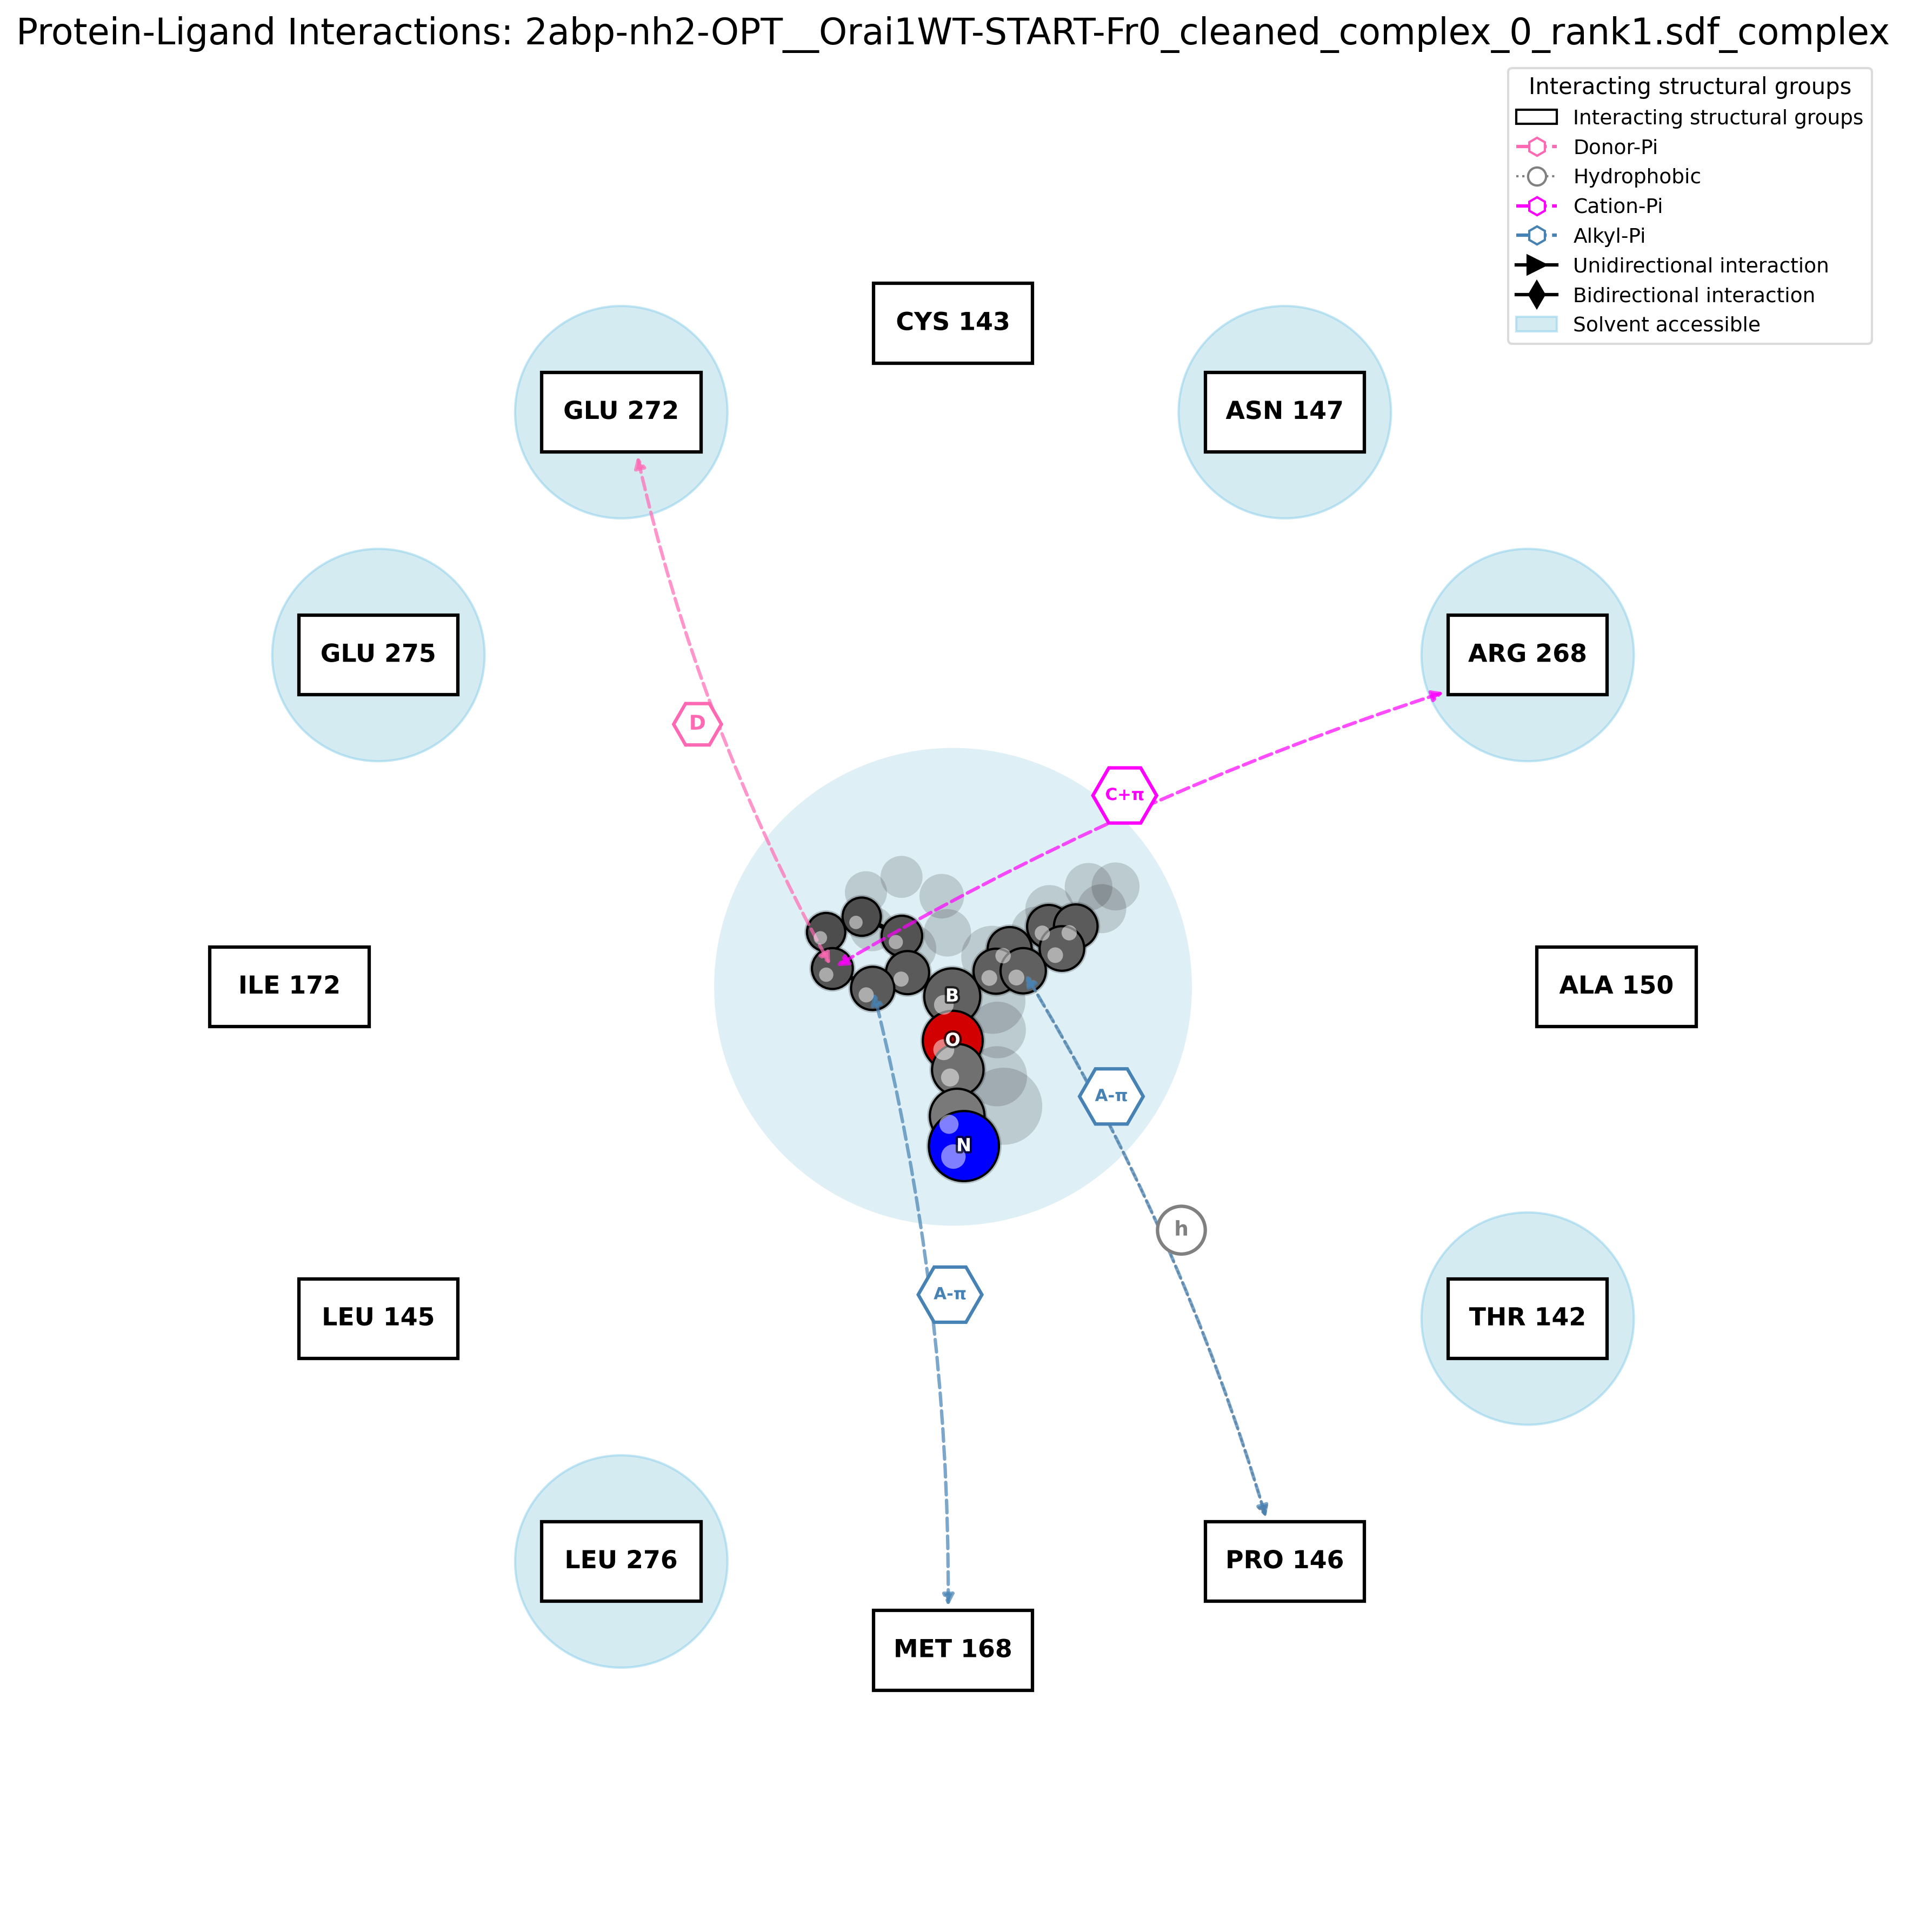


EQUIBIND_GUIDED: 2abp-nh2-OPT + Orai1WT-START-Fr0_cleaned
Total interactions: 3


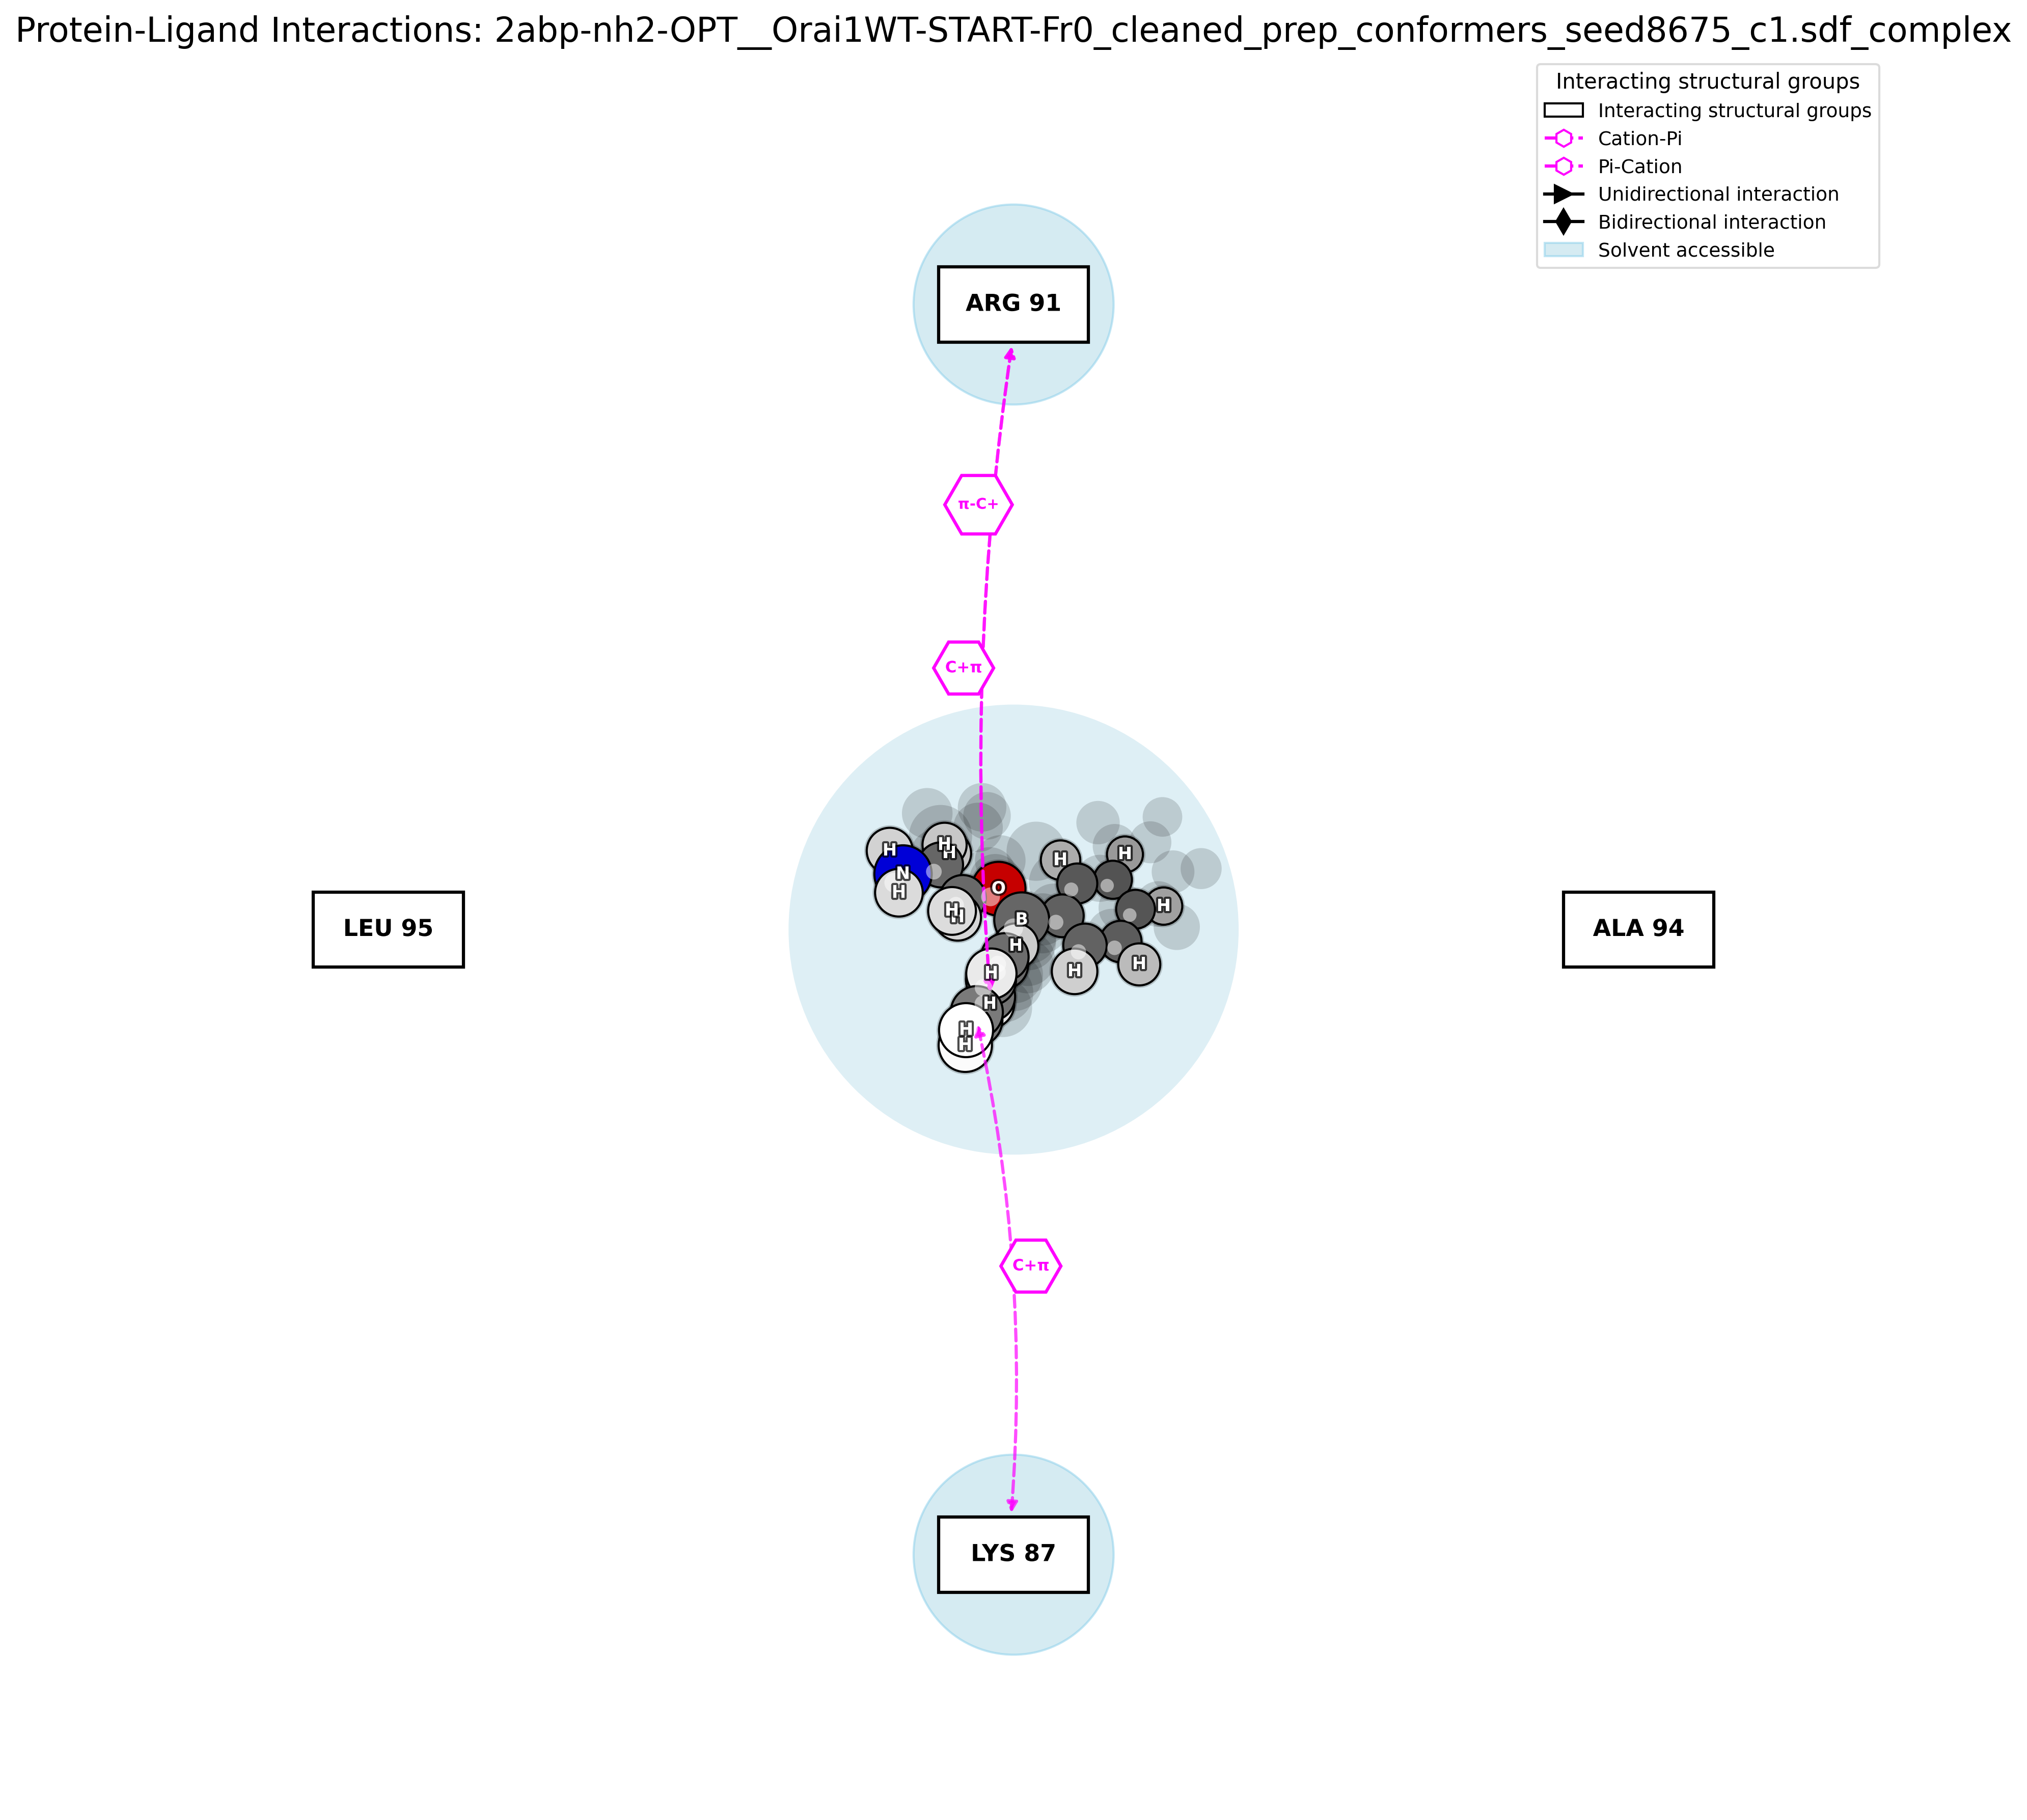


EUQIBIND_EXCLUSION: 2abp-nh2-OPT + Orai1WT-MDSnap-Fr499_cleaned
Total interactions: 14


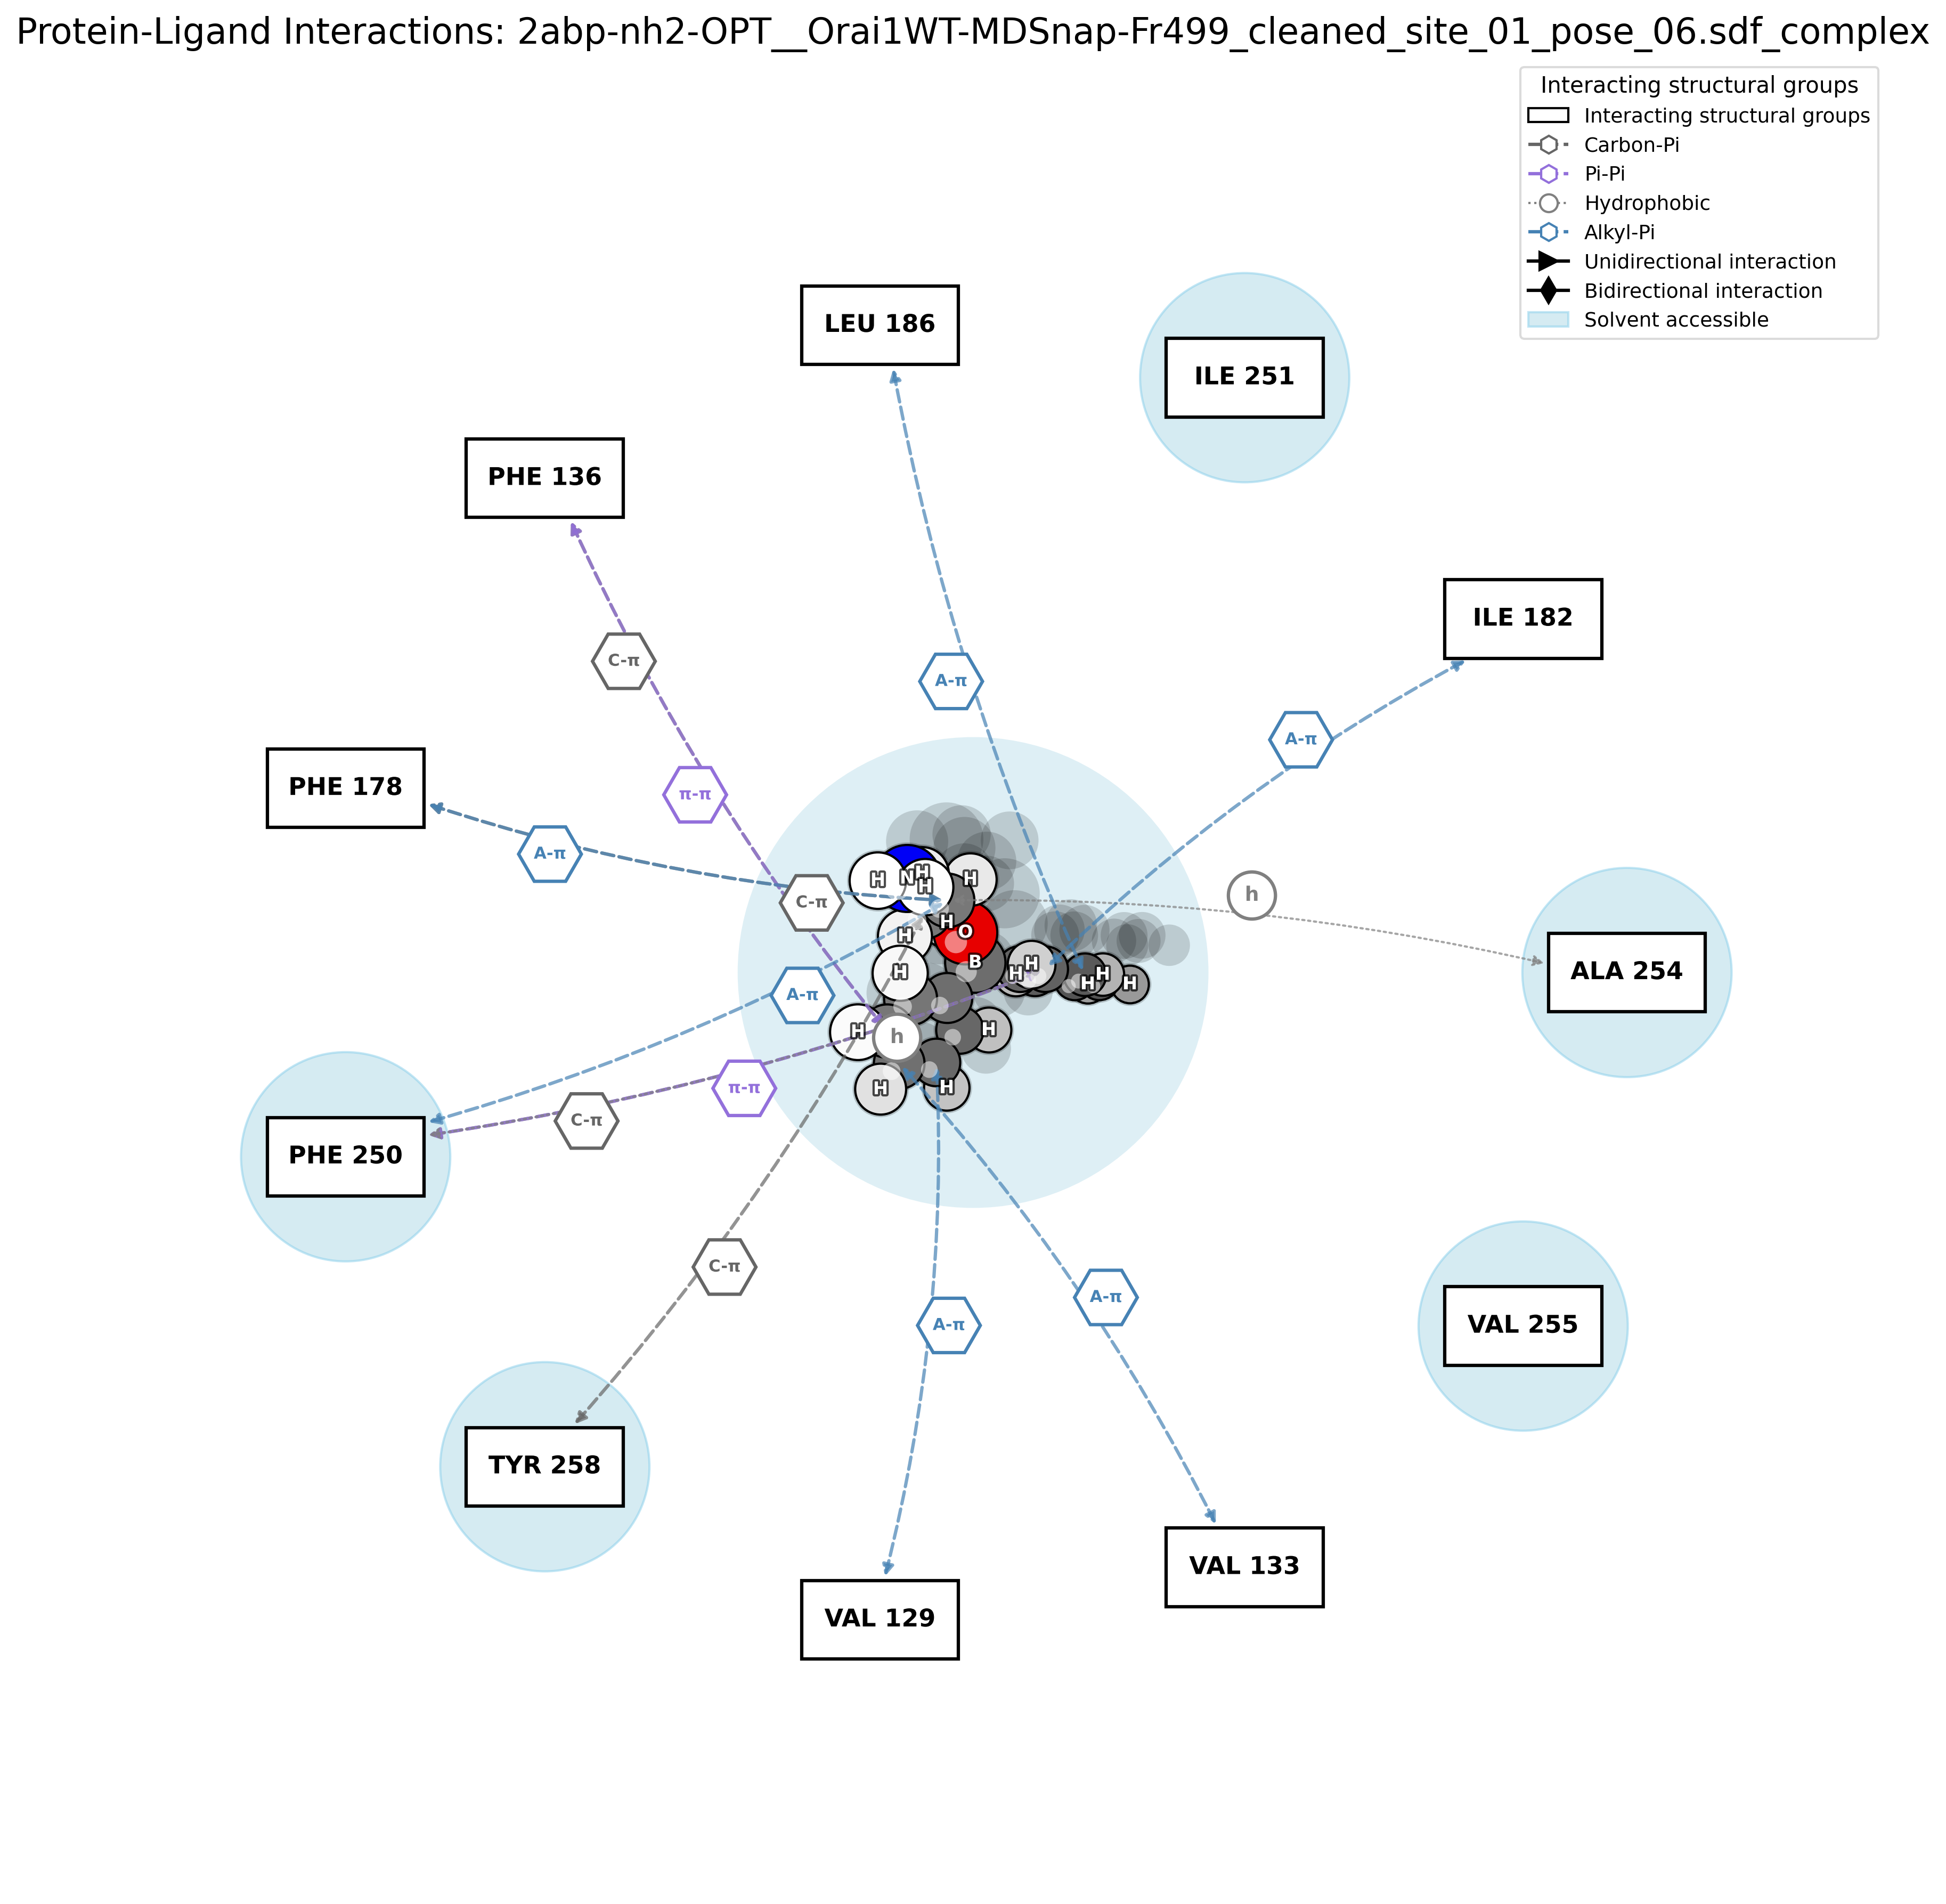

In [14]:
"""
Display sample interaction images — one per method (dynamic)
"""
from IPython.display import Image, display
import os

if results:
    print("Sample Interaction Maps:")
    print("=" * 60)

    for method in methods_found:
        method_results = [r for r in results if r["method"] == method]
        if method_results:
            sample = method_results[0]
            img_path = sample.get("output_image", "")
            if os.path.exists(img_path):
                print(f"\n{method.upper()}: {sample['ligand']} + {sample['protein']}")
                print(f"Total interactions: {sample['total_interactions']}")
                display(Image(filename=img_path, width=600))
            else:
                print(f"\n{method.upper()}: Image not found at {img_path}")
else:
    print("No results to display.")

In [15]:
# Full analysis on all selected poses is handled by Cell 7 above.
# This cell is kept as a placeholder — delete or skip.
print(f"Available methods: {methods_found}")
print(f"Total poses collected: {len(all_poses)}")
print(f"Representative poses: {len(selected_poses)}")

Available methods: ['autodock', 'diffdock', 'equibind_guided', 'euqibind_exclusion']
Total poses collected: 457
Representative poses: 28


In [16]:
"""
Generate PyMOL scripts from PandaMap results with synchronized interaction colors and labels.
Uses the EXACT same interaction types and color scheme as PandaMap visualization.
"""
import math
from pathlib import Path
from typing import Dict, List, Tuple

# ============================================================================
# PANDAMAP INTERACTION STYLES (EXACT MATCH)
# ============================================================================
# These match exactly the interaction_styles dict in pandamap/core.py
PANDAMAP_INTERACTION_STYLES = {
    'hydrogen_bonds': {
        'color': 'green',           # PandaMap: 'green'
        'pymol_color': 'green',
        'linestyle': '-',
        'marker_text': 'H',
        'name': 'Hydrogen Bond'
    },
    'carbon_pi': {
        'color': '#666666',         # PandaMap: '#666666' (gray)
        'pymol_color': '0x666666',
        'linestyle': '--',
        'marker_text': 'C-π',
        'name': 'Carbon-Pi'
    },
    'pi_pi_stacking': {
        'color': '#9370DB',         # PandaMap: '#9370DB' (medium purple)
        'pymol_color': '0x9370DB',
        'linestyle': '--',
        'marker_text': 'π-π',
        'name': 'Pi-Pi'
    },
    'donor_pi': {
        'color': '#FF69B4',         # PandaMap: '#FF69B4' (hot pink)
        'pymol_color': '0xFF69B4',
        'linestyle': '--',
        'marker_text': 'D',
        'name': 'Donor-Pi'
    },
    'amide_pi': {
        'color': '#A52A2A',         # PandaMap: '#A52A2A' (brown)
        'pymol_color': '0xA52A2A',
        'linestyle': '--',
        'marker_text': 'A',
        'name': 'Amide-Pi'
    },
    'hydrophobic': {
        'color': '#808080',         # PandaMap: '#808080' (gray)
        'pymol_color': '0x808080',
        'linestyle': ':',
        'marker_text': 'h',
        'name': 'Hydrophobic'
    },
    'ionic': {
        'color': '#FF4500',         # PandaMap: '#FF4500' (orange-red)
        'pymol_color': '0xFF4500',
        'linestyle': '-',
        'marker_text': 'I',
        'name': 'Ionic'
    },
    'halogen_bonds': {
        'color': '#00CED1',         # PandaMap: '#00CED1' (dark turquoise)
        'pymol_color': '0x00CED1',
        'linestyle': '-',
        'marker_text': 'X',
        'name': 'Halogen Bond'
    },
    'cation_pi': {
        'color': '#FF00FF',         # PandaMap: '#FF00FF' (magenta)
        'pymol_color': 'magenta',
        'linestyle': '--',
        'marker_text': 'C+π',
        'name': 'Cation-Pi'
    },
    'metal_coordination': {
        'color': '#FFD700',         # PandaMap: '#FFD700' (gold)
        'pymol_color': '0xFFD700',
        'linestyle': '-',
        'marker_text': 'M',
        'name': 'Metal Coordination'
    },
    'salt_bridge': {
        'color': '#FF6347',         # PandaMap: '#FF6347' (tomato)
        'pymol_color': '0xFF6347',
        'linestyle': '-',
        'marker_text': 'S',
        'name': 'Salt Bridge'
    },
    'covalent': {
        'color': '#000000',         # PandaMap: '#000000' (black)
        'pymol_color': 'black',
        'linestyle': '-',
        'marker_text': 'COV',
        'name': 'Covalent Bond'
    },
    'alkyl_pi': {
        'color': '#4682B4',         # PandaMap: '#4682B4' (steel blue)
        'pymol_color': '0x4682B4',
        'linestyle': '--',
        'marker_text': 'A-π',
        'name': 'Alkyl-Pi'
    },
    'attractive_charge': {
        'color': '#1E90FF',         # PandaMap: '#1E90FF' (dodger blue)
        'pymol_color': '0x1E90FF',
        'linestyle': '-',
        'marker_text': 'A+',
        'name': 'Attractive Charge'
    },
    'pi_cation': {
        'color': '#FF00FF',         # PandaMap: '#FF00FF' (magenta)
        'pymol_color': 'magenta',
        'linestyle': '--',
        'marker_text': 'π-C+',
        'name': 'Pi-Cation'
    },
    'repulsion': {
        'color': '#DC143C',         # PandaMap: '#DC143C' (crimson)
        'pymol_color': '0xDC143C',
        'linestyle': '-',
        'marker_text': 'R',
        'name': 'Repulsion'
    }
}

# ============================================================================
# RESIDUE NAME STANDARDIZATION (matching PandaMap behavior)
# ============================================================================
RESNAME_MAP = {
    # Histidine variants (CHARMM and AMBER)
    'HSD': 'HIS', 'HSE': 'HIS', 'HSP': 'HIS',
    'HID': 'HIS', 'HIE': 'HIS', 'HIP': 'HIS',
    # Cysteine variants
    'CYX': 'CYS', 'CYM': 'CYS',
    # Aspartate/Glutamate variants
    'ASH': 'ASP', 'GLH': 'GLU',
    # Lysine variants
    'LYN': 'LYS',
}

def standardize_resname(resname: str) -> str:
    """Convert non-standard residue names to standard 3-letter codes."""
    return RESNAME_MAP.get(resname, resname)

# Amino acid classifications for interaction type inference
AROMATIC_RESIDUES = {'PHE', 'TYR', 'TRP', 'HIS'}
HBOND_DONORS = {'ARG', 'LYS', 'HIS', 'ASN', 'GLN', 'SER', 'THR', 'TYR', 'TRP'}
HBOND_ACCEPTORS = {'ASP', 'GLU', 'ASN', 'GLN', 'HIS', 'SER', 'THR', 'TYR'}
NEG_CHARGED = {'ASP', 'GLU'}
POS_CHARGED = {'ARG', 'LYS', 'HIS'}
HYDROPHOBIC_RESIDUES = {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO', 'TYR'}
ALKYL_RESIDUES = {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PRO'}


def infer_interaction_type(resname: str, distance: float) -> str:
    """
    Infer the most likely interaction type based on residue type and distance.
    This attempts to match PandaMap's classification logic.
    """
    std_res = standardize_resname(resname)
    
    # Very close = likely hydrogen bond or ionic
    if distance < 3.5:
        if std_res in NEG_CHARGED or std_res in POS_CHARGED:
            return 'ionic'
        elif std_res in HBOND_DONORS or std_res in HBOND_ACCEPTORS:
            return 'hydrogen_bonds'
    
    # Medium range = could be pi-stacking, hydrophobic, or h-bonds
    if distance < 4.5:
        if std_res in AROMATIC_RESIDUES:
            return 'pi_pi_stacking'
        elif std_res in NEG_CHARGED or std_res in POS_CHARGED:
            return 'salt_bridge'
        elif std_res in HYDROPHOBIC_RESIDUES:
            return 'hydrophobic'
        elif std_res in HBOND_DONORS or std_res in HBOND_ACCEPTORS:
            return 'hydrogen_bonds'
    
    # Longer range = hydrophobic or alkyl-pi
    if std_res in ALKYL_RESIDUES:
        return 'alkyl_pi' if distance < 5.0 else 'hydrophobic'
    elif std_res in AROMATIC_RESIDUES:
        return 'carbon_pi'
    elif std_res in HYDROPHOBIC_RESIDUES:
        return 'hydrophobic'
    
    # Default
    return 'hydrophobic'


def generate_pymol_script_from_complex(complex_pdb: str, output_pml: str = None, cutoff: float = 5.0) -> str:
    """
    Generate PyMOL script from a PandaMap complex PDB file.
    Uses the exact same colors and label format as PandaMap 2D visualization.
    
    Args:
        complex_pdb: Path to complex PDB (protein + ligand with resn LIG)
        output_pml: Output path for PyMOL script (optional)
        cutoff: Distance cutoff for interacting residues (default 5Å)
    
    Returns:
        Path to generated PyMOL script
    """
    complex_path = Path(complex_pdb)
    
    # Read atoms from PDB
    protein_atoms = []
    ligand_atoms = []
    
    with open(complex_pdb, 'r') as f:
        for line in f:
            if line.startswith('ATOM'):
                resname = line[17:20].strip()
                chain = line[21].strip() or 'A'
                resnum = int(line[22:26])
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                atom_name = line[12:16].strip()
                element = line[76:78].strip() if len(line) > 76 else atom_name[0]
                protein_atoms.append((chain, resnum, resname, atom_name, element, x, y, z))
            elif line.startswith('HETATM'):
                resname = line[17:20].strip()
                if resname == 'LIG':
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    atom_name = line[12:16].strip()
                    element = line[76:78].strip() if len(line) > 76 else atom_name[0]
                    ligand_atoms.append((x, y, z, atom_name, element))
    
    # Find nearby residues and their minimum distances
    nearby_residues = {}
    for chain, resnum, resname, atom_name, element, px, py, pz in protein_atoms:
        for lx, ly, lz, _, _ in ligand_atoms:
            dist = math.sqrt((px-lx)**2 + (py-ly)**2 + (pz-lz)**2)
            if dist < cutoff:
                key = (chain, resnum, resname)
                if key not in nearby_residues:
                    nearby_residues[key] = dist
                else:
                    nearby_residues[key] = min(nearby_residues[key], dist)
    
    # Classify residues by inferred interaction type
    interactions_by_type = {itype: [] for itype in PANDAMAP_INTERACTION_STYLES.keys()}
    
    for (chain, resnum, resname), dist in nearby_residues.items():
        std_resname = standardize_resname(resname)
        itype = infer_interaction_type(resname, dist)
        interactions_by_type[itype].append((chain, resnum, resname, std_resname, dist))
    
    # Sort by residue number and remove duplicates
    for itype in interactions_by_type:
        seen = set()
        unique = []
        for item in sorted(interactions_by_type[itype], key=lambda x: x[1]):
            if item[1] not in seen:
                seen.add(item[1])
                unique.append(item)
        interactions_by_type[itype] = unique
    
    # Get the main chain
    main_chain = 'A'
    if nearby_residues:
        main_chain = list(nearby_residues.keys())[0][0] or 'A'
    
    complex_name = complex_path.stem
    
    # Build PyMOL script
    script_lines = [
        f'''# ============================================================================
# PyMOL Script - PandaMap Interactions Visualization
# Complex: {complex_name}
# Generated with PandaMap-synchronized colors and labels
# ============================================================================

# Clean slate
delete all
reinitialize

# Load complex
load {complex_path.resolve()}, complex

# Global settings
bg_color white
set antialias, 2
set ray_shadows, 0
set depth_cue, 1
set fog_start, 0.4
hide everything

# ============================================================================
# PROTEIN AND LIGAND DISPLAY
# ============================================================================
# Select components
select protein, complex and polymer.protein
select ligand, complex and resn LIG

# Show binding site region
select binding_region, protein within 12 of ligand
show cartoon, binding_region
color gray90, binding_region
set cartoon_transparency, 0.4, binding_region

# Ligand display - sticks with atom colors
show sticks, ligand
set stick_radius, 0.20, ligand
color atomic, ligand
color gray20, ligand and elem C

# ============================================================================
# INTERACTION-SPECIFIC SELECTIONS AND COLORING
# ============================================================================
'''
    ]
    
    # Generate selections for each interaction type
    interaction_summary = []
    
    for itype, style in PANDAMAP_INTERACTION_STYLES.items():
        residues = interactions_by_type.get(itype, [])
        if not residues:
            continue
        
        # Create residue selection string
        resi_list = '+'.join(str(r[1]) for r in residues)
        
        # PandaMap label format: "RESNAME RESNUM" (e.g., "HIS 123")
        # For PyMOL we'll create labels matching this format
        label_list = ', '.join(f"{r[3]} {r[1]}" for r in residues)
        
        selection_name = f"int_{itype}"
        pymol_color = style['pymol_color']
        display_name = style['name']
        
        script_lines.append(f'''
# {display_name} interactions
select {selection_name}, protein and chain {main_chain} and resi {resi_list}
show sticks, {selection_name}
set stick_radius, 0.15, {selection_name}
color {pymol_color}, {selection_name} and elem C
''')
        
        interaction_summary.append(f"{display_name}: {label_list}")
    
    # Add distance objects for visualizing interactions
    script_lines.append('''
# ============================================================================
# INTERACTION DISTANCE OBJECTS (dashed lines)
# ============================================================================
''')
    
    # Hydrogen bonds - green dashed lines
    if interactions_by_type.get('hydrogen_bonds'):
        resi = '+'.join(str(r[1]) for r in interactions_by_type['hydrogen_bonds'])
        script_lines.append(f'''
# Hydrogen bonds (green, solid)
distance hbonds, ligand and (elem N+O), (protein and chain {main_chain} and resi {resi}) and (elem N+O), 3.5, 2
color green, hbonds
set dash_width, 3, hbonds
set dash_gap, 0.15, hbonds
set dash_radius, 0.08, hbonds
hide labels, hbonds
''')
    
    # Ionic/Salt bridge - orange-red/tomato dashed lines
    ionic_resi = []
    if interactions_by_type.get('ionic'):
        ionic_resi.extend(str(r[1]) for r in interactions_by_type['ionic'])
    if interactions_by_type.get('salt_bridge'):
        ionic_resi.extend(str(r[1]) for r in interactions_by_type['salt_bridge'])
    if ionic_resi:
        resi = '+'.join(set(ionic_resi))
        script_lines.append(f'''
# Ionic/Salt bridge interactions (orange-red)
distance ionic, ligand and (elem N+O), (protein and chain {main_chain} and resi {resi}) and (elem N+O), 4.0, 2
color 0xFF4500, ionic
set dash_width, 3, ionic
set dash_gap, 0.2, ionic
set dash_radius, 0.08, ionic
hide labels, ionic
''')
    
    # Hydrophobic contacts - gray dotted lines
    if interactions_by_type.get('hydrophobic') or interactions_by_type.get('alkyl_pi'):
        hydro_resi = []
        if interactions_by_type.get('hydrophobic'):
            hydro_resi.extend(str(r[1]) for r in interactions_by_type['hydrophobic'])
        if interactions_by_type.get('alkyl_pi'):
            hydro_resi.extend(str(r[1]) for r in interactions_by_type['alkyl_pi'])
        resi = '+'.join(set(hydro_resi))
        script_lines.append(f'''
# Hydrophobic contacts (gray, dotted)
distance hydrophobic, ligand and elem C, (protein and chain {main_chain} and resi {resi}) and elem C, 4.5, 0
color 0x808080, hydrophobic
set dash_width, 2, hydrophobic
set dash_gap, 0.4, hydrophobic
set dash_radius, 0.06, hydrophobic
hide labels, hydrophobic
''')
    
    # Pi-stacking interactions - purple dashed lines
    pi_resi = []
    for pi_type in ['pi_pi_stacking', 'carbon_pi', 'cation_pi', 'pi_cation', 'donor_pi', 'amide_pi']:
        if interactions_by_type.get(pi_type):
            pi_resi.extend(str(r[1]) for r in interactions_by_type[pi_type])
    if pi_resi:
        resi = '+'.join(set(pi_resi))
        script_lines.append(f'''
# Pi-stacking interactions (purple, dashed)
distance pi_stack, ligand, protein and chain {main_chain} and resi {resi}, 5.5, 0
color 0x9370DB, pi_stack
set dash_width, 2.5, pi_stack
set dash_gap, 0.25, pi_stack
set dash_radius, 0.07, pi_stack
hide labels, pi_stack
''')
    
    # Halogen bonds - cyan
    if interactions_by_type.get('halogen_bonds'):
        resi = '+'.join(str(r[1]) for r in interactions_by_type['halogen_bonds'])
        script_lines.append(f'''
# Halogen bonds (cyan)
distance halogen, ligand and (elem CL+BR+I+F), (protein and chain {main_chain} and resi {resi}) and (elem N+O), 3.5, 2
color 0x00CED1, halogen
set dash_width, 3, halogen
set dash_gap, 0.15, halogen
hide labels, halogen
''')
    
    # Residue labels - matching PandaMap format: "RESNAME RESNUM"
    all_interacting_resi = set()
    for itype, residues in interactions_by_type.items():
        for r in residues:
            all_interacting_resi.add(r[1])
    
    if all_interacting_resi:
        resi_list = '+'.join(str(r) for r in sorted(all_interacting_resi))
        script_lines.append(f'''
# ============================================================================
# RESIDUE LABELS (PandaMap format: "RESNAME RESNUM")
# ============================================================================
select all_interacting, protein and chain {main_chain} and resi {resi_list}
label all_interacting and name CA, "%s %s" % (resn, resi)
set label_size, 14
set label_font_id, 7
set label_color, black
set label_bg_color, white
set label_bg_transparency, 0.3
set label_position, (1.5, 1.5, 2)
''')
    
    # Camera and final settings
    script_lines.append('''
# ============================================================================
# CAMERA AND FINAL SETTINGS
# ============================================================================
zoom ligand, 8
center ligand
orient ligand
turn y, 20
turn x, -10

deselect
''')
    
    # Print interaction summary
    script_lines.append('\n# ============================================================================')
    script_lines.append('# INTERACTION SUMMARY (PandaMap-style labels)')
    script_lines.append('# ============================================================================')
    for summary in interaction_summary:
        script_lines.append(f'print("{summary}")')
    
    script = '\n'.join(script_lines)
    
    # Save script
    if output_pml is None:
        output_pml = complex_path.with_suffix('.pml')
    else:
        output_pml = Path(output_pml)
    
    with open(output_pml, 'w') as f:
        f.write(script)
    
    return str(output_pml)


# Test and display info
print("PyMOL script generator loaded with PandaMap-synchronized colors!")
print("\n" + "=" * 60)
print("PANDAMAP INTERACTION COLOR SCHEME")
print("=" * 60)
for itype, style in PANDAMAP_INTERACTION_STYLES.items():
    print(f"  {style['name']:20s}: {style['color']:10s} (marker: {style['marker_text']})")

PyMOL script generator loaded with PandaMap-synchronized colors!

PANDAMAP INTERACTION COLOR SCHEME
  Hydrogen Bond       : green      (marker: H)
  Carbon-Pi           : #666666    (marker: C-π)
  Pi-Pi               : #9370DB    (marker: π-π)
  Donor-Pi            : #FF69B4    (marker: D)
  Amide-Pi            : #A52A2A    (marker: A)
  Hydrophobic         : #808080    (marker: h)
  Ionic               : #FF4500    (marker: I)
  Halogen Bond        : #00CED1    (marker: X)
  Cation-Pi           : #FF00FF    (marker: C+π)
  Metal Coordination  : #FFD700    (marker: M)
  Salt Bridge         : #FF6347    (marker: S)
  Covalent Bond       : #000000    (marker: COV)
  Alkyl-Pi            : #4682B4    (marker: A-π)
  Attractive Charge   : #1E90FF    (marker: A+)
  Pi-Cation           : #FF00FF    (marker: π-C+)
  Repulsion           : #DC143C    (marker: R)


In [17]:
"""
Generate PyMOL scripts for analyzed complexes
"""
# Generate PyMOL scripts for all successful results
pymol_scripts = []

if results:
    print("Generating PyMOL scripts for analyzed complexes...")
    print("=" * 60)
    
    for result in results[:5]:  # First 5 for demo
        output_image = result.get("output_image", "")
        if output_image:
            # Complex PDB is in the same directory
            complex_dir = Path(output_image).parent
            complex_files = list(complex_dir.glob("*_complex.pdb"))
            
            if complex_files:
                complex_pdb = complex_files[0]
                pml_path = generate_pymol_script_from_complex(str(complex_pdb))
                pymol_scripts.append(pml_path)
                print(f"  Generated: {Path(pml_path).name}")
    
    print(f"\n{len(pymol_scripts)} PyMOL scripts generated.")
    print("\nTo use in PyMOL, run:")
    if pymol_scripts:
        print(f"  @{pymol_scripts[0]}")
else:
    print("No results available. Run PandaMap analysis first.")

Generating PyMOL scripts for analyzed complexes...

0 PyMOL scripts generated.

To use in PyMOL, run:
